## 3장 2강: 로지스틱 회귀와 교차 검증

### 1. 로지스틱 회귀: 선형 회귀로 분류를 해결하는 마법
#### 1.5 범주형 데이터 전처리: 원핫 인코딩의 명과 암

원핫 인코딩 실습

실습에 필요한 도구 불러오기

In [19]:
from sklearn.preprocessing import OneHotEncoder


간단한 가상의 과일 범주 데이터를 준비합니다.

In [20]:
data = pd.DataFrame({'과일': ['사과','바나나','딸기','바나나']}) #클래스는 3개
data

,과일
0,사과
1,바나나
2,딸기
3,바나나


원핫 인코딩 변환

In [21]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(data[['과일']])

encoded_data

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

변환 결과를 보기 좋게 판다스 데이터프레임으로 만들어 출력합니다.

### 3. 붓꽃 데이터(Iris) 이진 및 다중 분류 실습
#### 3.1 데이터 불러오기 및 학습 준비

실습에 필요한 도구 불러오기

In [22]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt # 차트 그릴거
from matplotlib.colors import ListedColormap #차트 예쁘게 컬러 넣기
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


붓꽃 데이터셋(Iris.csv) 불러오기

In [23]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

실습 1. 이진 분류용 데이터 구성

In [25]:
df_binary = df[df['Species'].isin(['Iris-setosa','Iris-versicolor'])].copy()

#꽃잎의 넓이와 높이를 2차원으로 추출 # stratify=y_binary : 비율을 고정적으로 맞춰주는 것

X_binary = df_binary[["PetalLengthCm","PetalWidthCm"]]  
y_binary = df_binary['Species'].map({'Iris-setosa': 0, 'Iris-versicolor' : 1})

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_binary,y_binary, test_size=0.2, random_state=42, stratify=y_binary

)
X_binary.head()


,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [26]:
y_binary.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [29]:
# 이진 분류 모델 학습
binary_model = LogisticRegression()
binary_model.fit(X_bin_train,y_bin_train)

bin_test_preds = binary_model.predict(X_bin_test)


print(bin_test_preds)
print(y_bin_test.values)
bin_accuracy = accuracy_score(y_bin_test, bin_test_preds)
print(f"이진 분류 테스트 정확도:{bin_accuracy:.4f}")

[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
이진 분류 테스트 정확도:1.0000


실습 2. 다중 분류용 데이터 구성

In [30]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [35]:
X_multi = df[["PetalLengthCm", "PetalWidthCm"]]
y_multi = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})
X_multi.head()

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [36]:
y_multi.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

#### 3.2 모델 학습 및 결정 경계(Decision Boundary) 시각화
모델 학습 및 교차 검증하기

In [37]:
# 다중 분류 훈련세트, 테스트 세트

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,y_multi, test_size=0.2, random_state=42, stratify=y_multi

)


In [45]:
# 다중 분류 모델 학습
multi_model = LogisticRegression()


# 교차검증(k-Fold) / # shuffle=True 옵션으로 데이터를 고르게 섞고, random_state로 난수를 고정하여 일관성 보장!
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train , cv=kf)
print("cv_scores:",cv_scores)
print("교차 검증 정확도 평균:%.4f" % cv_scores.mean())

multi_model.fit(X_multi_train,y_multi_train)

multi_test_preds = multi_model.predict(X_multi_test)
print("예측값:", multi_test_preds)
print("원래값:",y_multi_test.values)


multi_accuracy = accuracy_score(y_multi_test, multi_test_preds)

cv_scores: [0.91666667 0.95833333 0.95833333 1.         0.95833333]
교차 검증 정확도 평균:0.9583
예측값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
원래값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


두 가지 실습 결과를 한눈에 비교하기 위한 Matplotlib 시각화

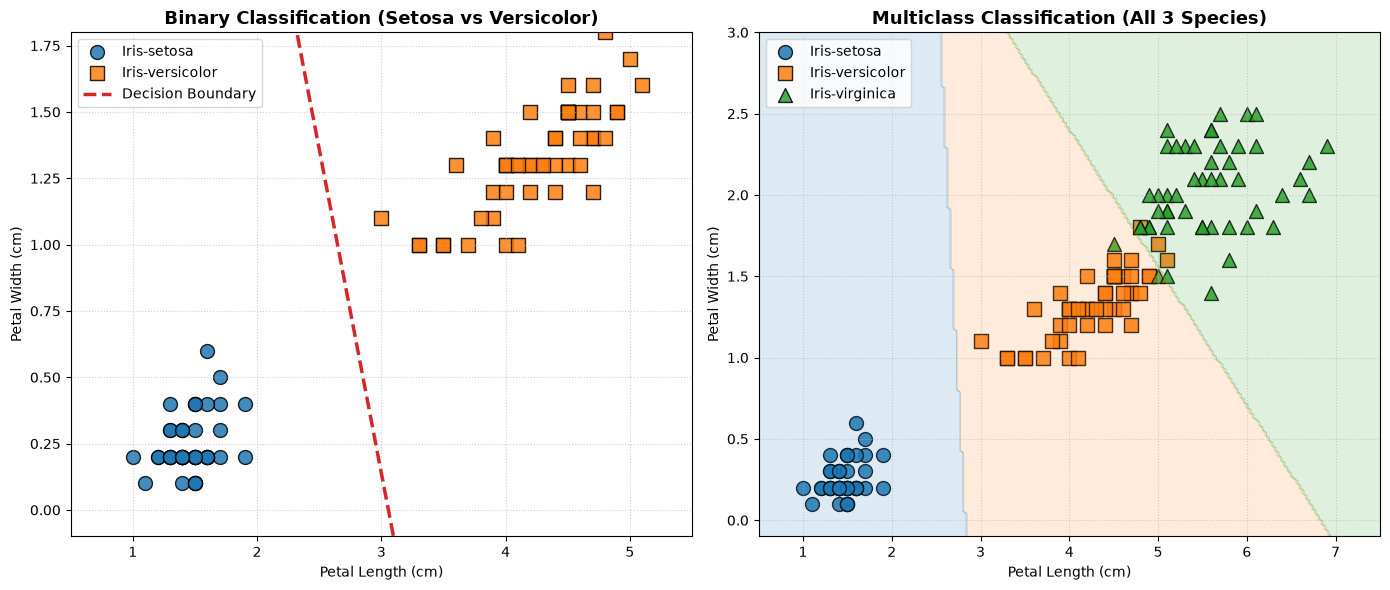

In [47]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [왼쪽 플롯] 이진 분류 선형 결정 경계선
ax1 = axes[0]

colors_binary = ['#1F77B4', '#FF7F0E']
markers_binary = ['o', 's']
species_binary = ['Iris-setosa', 'Iris-versicolor']

for species, color, marker in zip(
    species_binary,
    colors_binary,
    markers_binary
):
    subset = df_binary[df_binary['Species'] == species]

    ax1.scatter(
        subset['PetalLengthCm'],
        subset['PetalWidthCm'],
        label=species,
        color=color,
        marker=marker,
        s=100,
        edgecolor='black',
        alpha=0.85
    )

# 결정 경계 계산
w1 = binary_model.coef_[0][0]
w2 = binary_model.coef_[0][1]
b = binary_model.intercept_[0]

x_vals = np.linspace(0.8, 5.2, 100)
y_vals = -(w1 * x_vals + b) / w2

ax1.plot(
    x_vals,
    y_vals,
    '--',
    color='#D62728',
    linewidth=2.5,
    label='Decision Boundary'
)

ax1.set_title(
    "Binary Classification (Setosa vs Versicolor)",
    fontsize=13,
    fontweight='bold'
)
ax1.set_xlabel("Petal Length (cm)")
ax1.set_ylabel("Petal Width (cm)")
ax1.set_xlim(0.5, 5.5)
ax1.set_ylim(-0.1, 1.8)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)


# [오른쪽 플롯] 다중 분류 영역
ax2 = axes[1]

colors_multi = {
    'Iris-setosa': '#1F77B4',
    'Iris-versicolor': '#FF7F0E',
    'Iris-virginica': '#2CA02C'
}

markers_multi = {
    'Iris-setosa': 'o',
    'Iris-versicolor': 's',
    'Iris-virginica': '^'
}

for species in [
    'Iris-setosa',
    'Iris-versicolor',
    'Iris-virginica'
]:
    subset = df[df['Species'] == species]

    ax2.scatter(
        subset['PetalLengthCm'],
        subset['PetalWidthCm'],
        label=species,
        color=colors_multi[species],
        marker=markers_multi[species],
        s=100,
        edgecolor='black',
        alpha=0.85
    )

# 그래프 전체 영역에 격자 생성
xx, yy = np.meshgrid(
    np.linspace(0.5, 7.5, 200),
    np.linspace(-0.1, 3.0, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

grid_df = pd.DataFrame(
    grid_points,
    columns=['PetalLengthCm', 'PetalWidthCm']
)

# 각 격자 위치의 클래스 예측
Z_pred = multi_model.predict(grid_df)

# 이미 0, 1, 2로 예측되므로 그대로 reshape
Z_num = np.array(Z_pred).reshape(xx.shape)

# 예측 영역 색칠
custom_cmap = ListedColormap([
    '#1F77B4',
    '#FF7F0E',
    '#2CA02C'
])

ax2.contourf(
    xx,
    yy,
    Z_num,
    alpha=0.15,
    cmap=custom_cmap
)

ax2.set_title(
    "Multiclass Classification (All 3 Species)",
    fontsize=13,
    fontweight='bold'
)
ax2.set_xlabel("Petal Length (cm)")
ax2.set_ylabel("Petal Width (cm)")
ax2.set_xlim(0.5, 7.5)
ax2.set_ylim(-0.1, 3.0)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 수업 내용
----
1. 이진 분류
- 활성 함수 : 시그모이드 함수 (0~1)
    - 로짓 = 모델이 계산한 원점수
    - Sigmoid = 그 원점수를 확률처럼 0~1로 바꿔주는 함수


**아카이브 하고 / 개념 정리해 줄 내용 정리한다. 
머신러닝 모델의 지도학습 - 회귀/분류 2가지 학습 과정이 있다.

선형회귀를 이용해서 나온 예측값이 로직값
분류를 할때, a 값으로 분류되거나 b값으로 분류될 "확률" 적으로 계산할 수 있게 바꿔주는 함수가 활성화 함수
시그노이어 함수이고 0과1사이로 로직값을 압축
0.5를 기준으로 양성/음성을 판단한다 -> 바이너리 클래시피케이션 / 이진분류


가중치와 절편은 계속적 학습으로 계속 업데이트 해간다
loss값이 가중치/절편의 학습 기준이다
loss값으로 그라디언트를 만들어서 이것들을 판단해 최적의 가중치를 만든다.
손실함수(로스펑션)이 꼭 필요하다
MSE : 얘도 벌점 주는 것
크로스앤트로피 : 틀리면 훨씬더 LOSS를 올려버리고 벌점을 준다. 무한대의 가까운 벌점을 폭탄처럼 줘버리는 것
BCE(이진 크로스 엔트로피) 
CCE(범주형 크로스 엔트로피)
SCCE(희소 범주형 크로스 엔트로피)

이진분류
- 활성 함수 : 시그노이드

다중 분류
- 활성 함수 : 소프트 맥스(SOFT-MAX) 
    - 각각의 클래스 총합을 1로 해서 클래스를 분류 (높은 확률을 정답으로 채택)

    - 원핫 인코딩(One-Hot Encoding) :컴퓨터에게 '편견 없는 글자 교육'을 시키는 변환 도구 
        - 클래스명(문자열) -> 숫자로 변환해 총합 1로 변환
        김민수  김영희  김철수
        [1,0,0] [0,1,0] [0,0,1]

        - 원핫 인코딩의 한계
            : 분류 갯수가 많아지면 메모리가 부족해지고, 연산량도 많아진다.
        - 그래서, 활성함수 : SCCE (희소 범주형 크로스 엔트로피) :  정수로 받고, 내부적으로 해당 인덱스의 확률을 계산해준다
        - 또, 실수 밀집 벡터(임베딩 레이어/ Embedding Layer)
            대안 1: SCCE(희소 범주형 크로스 엔트로피)
                학습용 데이터($X$)가 아닌 최종 타깃 데이터($y$)를 인코딩할 때 메모리를 획기적으로 아낄 수 있는 방법입니다. 정답 데이터를 다차원 원-핫 배열로 변환하지 않고 0, 1, 2와 같은 정수형태 그대로 유지하며, 내부적인 수학 연산을 통해 다중 분류 손실을 계산하므로 메모리 효율성이 매우 뛰어납니다.

            대안 2: 임베딩 레이어(Embedding Layer)
                딥러닝에서 처리해야 할 범주(Category)가 수만 개를 넘어설 때 선택하는 가장 효과적인 전처리 기법입니다. 수만 개의 0으로 가득 찬 불필요한 공간(희소 벡터)을 버리고, 실수 형태의 고밀도 연속 벡터 공간(Dense Vector)으로 압축하여 맵핑합니다. 덕분에 정보의 손실 없이도 학습 및 연산 속도를 대폭 끌어올릴 수 있습니다.


- 손실함수(LOSS FUNCTION)
    - CCE(범주형 크로스 엔트로피)
        - 꼭꼭 원핫인코딩이 필수이며 한계가 있다
    - SCCE(희소 범주형 크로스 엔트로피)
        - 정수형 레이블 / 정답 인덱스의 확률값만 추출하여 연산

-  K-Fold 교차 검증 (Cross Validation)
- 




- 오버피팅(Overfitting) 개념과 예시?
- random_state=42 : 왜? 42?
- random_state는 왜 고정할까요?
    - 모든 수강생들의 결과 화면을 통일하고 일관된 피드백을 제공하기 위한 '재현성' 목적